In [1]:
import os
import cv2
import mmap
import numpy
import IPython.display
def meow(*meows):
    print("\U0001F43E", *meows, "nyaa~")

In [2]:
meow("Setting up workspace")
os.makedirs("/content/radar/", exist_ok=True)
os.chdir("/content/radar/")
meow("Workspace is all ready in", os.getcwd())
meow("Downloading radar data")
if not os.path.exists("data.zip"):
    address = (
        "https://drive.google.com/file/d/"
        "179VNSmTTIsG2TUX4M-VLIqw3yu3hjs9e/"
        "view?usp=drivesdk"
    )
    !gdown --fuzzy "$address" -O "data.zip" -q
meow("Yay, radar data finished downloading")
meow("Opening up radar data")
if not os.path.exists("meow.nyaa"):
    !rm -rf "data"
    !unzip -q "data.zip" -d "data"
    !touch "meow.nyaa"
meow("Radar data is unpacked")
meow("Bringing in calibration data")
if not os.path.exists("calibration.npy"):
    address = (
        "https://raw.githubusercontent.com/"
        "LiuLiu-55/ROFusion/main/"
        "CalibrationTable.npy"
    )
    !wget -q "$address" -O "calibration.npy"
meow("Sweet, calibration data is here")
recording = (
    "data/"
    "RECORD@2020-11-21_12.11.17/"
    "RECORD@2020-11-21_12.11.17"
)
sensor_drift = {
    "camera": 0,
    "radar_ch0": -180000,
    "radar_ch1": -180000,
    "radar_ch2": -180000,
    "radar_ch3": -180000
}
stream = {
    sensor: {
        "time": [],
        "issued": [],
        "sample": []
    }
    for sensor in sensor_drift
}
for line in open(recording + "_events_log.rec"):
    bits = line.split()
    if bits[10] in stream:
        stream[bits[10]]["time"].append(int(bits[1]))
        stream[bits[10]]["issued"].append(int(bits[4]))
        stream[bits[10]]["sample"].append(int(bits[7]))
for sensor, data in stream.items():
    shift = (
        data["issued"][0] -
        data["time"][0] +
        sensor_drift[sensor]
        if data["time"] else 0
    )
    data["time"] = shift + numpy.asarray(
        data["time"], dtype=numpy.int64
    )
    data["sample"] = numpy.asarray(
        data["sample"], dtype=numpy.int64
    )
camera_to_radar = {}
master = stream["radar_ch3"]
for index in range(len(master["time"])):
    sample_id = master["sample"][index]
    channel0 = numpy.where(stream["radar_ch0"]["sample"] == sample_id + 1)[0]
    channel1 = numpy.where(stream["radar_ch1"]["sample"] == sample_id + 3)[0]
    channel2 = numpy.where(stream["radar_ch2"]["sample"] == sample_id + 2)[0]
    if not (len(channel0) and len(channel1) and len(channel2)):
        continue
    gap = numpy.abs(stream["camera"]["time"] - master["time"][index])
    cam = int(gap.argmin())
    if gap[cam] > 20000:
        continue
    camera_to_radar[cam] = [
        int(channel0[0]),
        int(channel1[0]),
        int(channel2[0]),
        index
    ]
meow("Caught", len(camera_to_radar), "frames")
print("\U0001F43E")
indices = sorted(camera_to_radar)
for index in range(0, len(indices), 4):
    meow(
        "\t", indices[index],
        "\t", indices[index + 1],
        "\t", indices[index + 2],
        "\t", indices[index + 3], "\t"
    )
print("\U0001F43E")
meow("Choose one")

🐾 Setting up workspace nyaa~
🐾 Workspace is all ready in /content/radar nyaa~
🐾 Downloading radar data nyaa~
🐾 Yay, radar data finished downloading nyaa~
🐾 Opening up radar data nyaa~
🐾 Radar data is unpacked nyaa~
🐾 Bringing in calibration data nyaa~
🐾 Sweet, calibration data is here nyaa~
🐾 Caught 548 frames nyaa~
🐾
🐾 	 3 	 15 	 27 	 317 	 nyaa~
🐾 	 322 	 326 	 331 	 335 	 nyaa~
🐾 	 340 	 345 	 351 	 357 	 nyaa~
🐾 	 362 	 370 	 376 	 382 	 nyaa~
🐾 	 387 	 393 	 399 	 405 	 nyaa~
🐾 	 410 	 420 	 426 	 432 	 nyaa~
🐾 	 437 	 443 	 449 	 455 	 nyaa~
🐾 	 461 	 466 	 472 	 478 	 nyaa~
🐾 	 484 	 489 	 495 	 501 	 nyaa~
🐾 	 507 	 513 	 518 	 524 	 nyaa~
🐾 	 530 	 536 	 541 	 547 	 nyaa~
🐾 	 553 	 559 	 565 	 570 	 nyaa~
🐾 	 576 	 582 	 588 	 593 	 nyaa~
🐾 	 599 	 605 	 611 	 617 	 nyaa~
🐾 	 622 	 628 	 634 	 640 	 nyaa~
🐾 	 645 	 651 	 657 	 663 	 nyaa~
🐾 	 669 	 674 	 680 	 686 	 nyaa~
🐾 	 692 	 697 	 703 	 709 	 nyaa~
🐾 	 715 	 721 	 726 	 732 	 nyaa~
🐾 	 738 	 744 	 749 	 755 	 nyaa~
🐾 	 

In [3]:
camera_frame_index = 715
meow("Looking at frame", camera_frame_index)

🐾 Looking at frame 715 nyaa~


🐾 Computing constants nyaa~
🐾 Pulling radar bin frames [80, 75, 76, 110] nyaa~
🐾 Reshaping four chips in physical firing order nyaa~
🐾 Running range FFT then doppler FFT with Hamming windows nyaa~
🐾 Loading calibration table nyaa~
🐾 Building doppler scramble pattern for MIMO synthesis nyaa~
🐾 Multiplying calibration matrix to reach azimuth domain nyaa~
🐾 Squashing doppler away to leave flat range-by-angle map nyaa~
🐾 Subtracting noise floor and softening with tiny blur nyaa~
🐾 Setting up top-down canvas centered on radar nyaa~
🐾 Asking each canvas pixel where it lives in polar coordinates nyaa~
🐾 Marking which pixels fall inside radar field of view nyaa~
🐾 Looking up range bin and angle bin for each pixel nyaa~
🐾 Pouring polar map onto cartesian canvas nyaa~
🐾 Squeezing dynamic range and applying summer colormap nyaa~



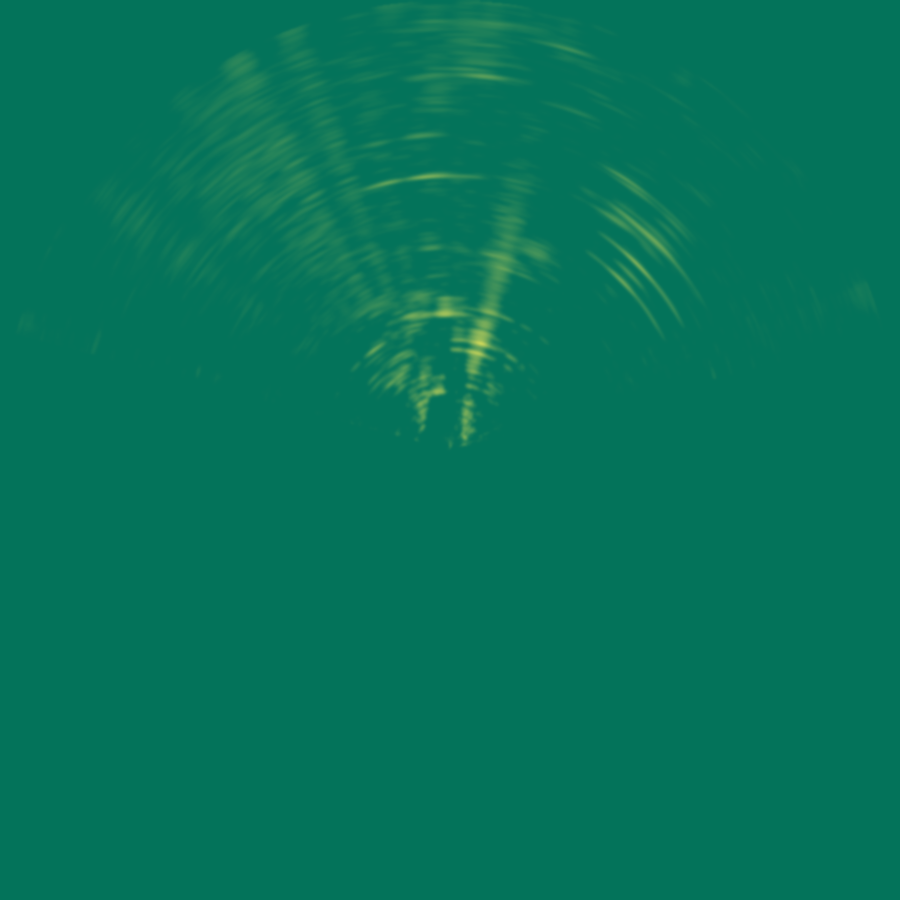

In [4]:
meow("Computing constants")
radar_frame_indices = camera_to_radar[camera_frame_index]
radar_paths = [
    recording + "_radar_ch" + str(i) + ".bin"
    for i in range(4)
]
samples_per_chirp = 512
chirps_per_frame = 256
receivers_per_chip = 4
int16_values_per_frame = (
    samples_per_chirp * receivers_per_chip * chirps_per_frame * 2
)
bytes_per_frame = int16_values_per_frame * 2
meow("Pulling radar bin frames", radar_frame_indices)
chip_samples = [
    numpy.fromfile(
        path, dtype=numpy.int16,
        count=int16_values_per_frame,
        offset=index * bytes_per_frame
    )
    for path, index in zip(radar_paths, radar_frame_indices)
]
meow("Reshaping four chips in physical firing order")
chips = []
for chip_index in (3, 0, 1, 2):
    samples = chip_samples[chip_index]
    chips.append(numpy.reshape(
        samples[0::2] + 1j * samples[1::2],
        (samples_per_chirp, receivers_per_chip, chirps_per_frame),
        order="F"
    ).transpose((0, 2, 1)))
radar_cube = numpy.concatenate(chips, axis=2).astype(numpy.complex64)
radar_cube -= numpy.mean(radar_cube, axis=(0, 1), keepdims=True)
meow("Running range FFT then doppler FFT with Hamming windows")
hamming_range = 0.54 - 0.46 * numpy.cos(
    (2 * numpy.pi * numpy.arange(samples_per_chirp))
    / (samples_per_chirp - 1)
)
hamming_doppler = 0.54 - 0.46 * numpy.cos(
    (2 * numpy.pi * numpy.arange(chirps_per_frame))
    / (chirps_per_frame - 1)
)
range_window = hamming_range[:, None, None]
doppler_window = hamming_doppler[None, :, None]
range_fft = numpy.fft.fft(
    radar_cube * range_window,
    n=samples_per_chirp, axis=0
)
radar_fft = numpy.fft.fft(
    range_fft * doppler_window,
    n=chirps_per_frame, axis=1
).astype(numpy.complex64)
meow("Loading calibration table")
calibration = numpy.load("calibration.npy", allow_pickle=True).item()
azimuth_degrees = numpy.asarray(
    calibration["Azimuth_table"], dtype=numpy.float32
)
calibration_window = numpy.asarray(
    calibration["H"][0], dtype=numpy.complex64
)
calibration_matrix = numpy.asarray(
    calibration["Signal"][..., 5], dtype=numpy.complex64
)
meow("Building doppler scramble pattern for MIMO synthesis")
mimo_doppler_offsets = numpy.arange(0, 16 * 16, 16)
doppler_indices = []
for doppler_bin in range(0, chirps_per_frame, 2):
    doppler_sequence = numpy.remainder(
        doppler_bin + mimo_doppler_offsets, chirps_per_frame
    )
    doppler_sequence = numpy.concatenate([
        [doppler_sequence[0]],
        doppler_sequence[5:]
    ])
    doppler_indices.append(doppler_sequence)
doppler_indices = numpy.asarray(doppler_indices, dtype=numpy.int32)
meow("Multiplying calibration matrix to reach azimuth domain")
mimo_spectrum = radar_fft[:, doppler_indices, :].reshape(
    radar_fft.shape[0] * doppler_indices.shape[0], -1
)
mimo_spectrum = (mimo_spectrum * calibration_window).T
azimuth_spectrum = numpy.abs(
    numpy.dot(calibration_matrix, mimo_spectrum)
)
azimuth_spectrum = azimuth_spectrum.reshape(
    len(azimuth_degrees),
    radar_fft.shape[0],
    doppler_indices.shape[0]
)
meow("Squashing doppler away to leave flat range-by-angle map")
polar_map = numpy.log10(
    numpy.sum(numpy.abs(azimuth_spectrum), axis=2) + 1e-6
)
polar_map -= polar_map.min()
if polar_map.max() > 0:
    polar_map = polar_map / polar_map.max()
polar_map = polar_map.T.astype(numpy.float32)
meow("Subtracting noise floor and softening with tiny blur")
noise_floor = numpy.percentile(polar_map, 72, axis=1, keepdims=True)
polar_map = numpy.clip(polar_map - noise_floor, 0, None)
polar_map = cv2.GaussianBlur(polar_map, (0, 0), 1.0)
if polar_map.max() > 0:
    polar_map = polar_map / polar_map.max()
meow("Setting up top-down canvas centered on radar")
max_range_meters = 103.0
meters_per_range_bin = max_range_meters / samples_per_chirp
canvas_size = 900
meow("Asking each canvas pixel where it lives in polar coordinates")
x_axis = numpy.linspace(
    -max_range_meters, max_range_meters, canvas_size,
    dtype=numpy.float32
)
y_axis = numpy.linspace(
    max_range_meters, -max_range_meters, canvas_size,
    dtype=numpy.float32
)
grid_x, grid_y = numpy.meshgrid(x_axis, y_axis)
pixel_range = numpy.sqrt(grid_x ** 2 + grid_y ** 2)
pixel_angle = numpy.degrees(numpy.arctan2(-grid_x, grid_y))
meow("Marking which pixels fall inside radar field of view")
inside_field_of_view = (
    (pixel_range <= max_range_meters)
    & (pixel_angle >= float(azimuth_degrees.min()))
    & (pixel_angle <= float(azimuth_degrees.max()))
)
meow("Looking up range bin and angle bin for each pixel")
range_indices = numpy.clip(
    pixel_range / meters_per_range_bin, 0, polar_map.shape[0] - 1
).astype(numpy.float32)
angle_indices = numpy.interp(
    pixel_angle, azimuth_degrees,
    numpy.arange(len(azimuth_degrees), dtype=numpy.float32)
).astype(numpy.float32)
meow("Pouring polar map onto cartesian canvas")
warped = cv2.remap(
    polar_map, angle_indices, range_indices,
    interpolation=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=0
)
canvas = warped * inside_field_of_view
meow("Squeezing dynamic range and applying summer colormap")
canvas = numpy.clip(canvas, 0.0, 1.0) ** 0.72
minimap = numpy.uint8(numpy.clip(canvas * 255.0, 0, 255))
minimap = cv2.GaussianBlur(minimap, (0, 0), 1.2)
minimap = cv2.applyColorMap(minimap, cv2.COLORMAP_SUMMER)
minimap = cv2.addWeighted(
    minimap, 0.86,
    numpy.full_like(minimap, (18, 32, 20)), 0.14, 0
)
print()
_, png = cv2.imencode(".png", minimap)
IPython.display.display(IPython.display.Image(png.tobytes()))

🐾 Picking dominant doppler bin at every range and angle pixel nyaa~
🐾 Warping polar velocity onto cartesian canvas nyaa~
🐾 Lifting radial velocity to world vector nyaa~
🐾 Encoding velocity in normal-map style nyaa~



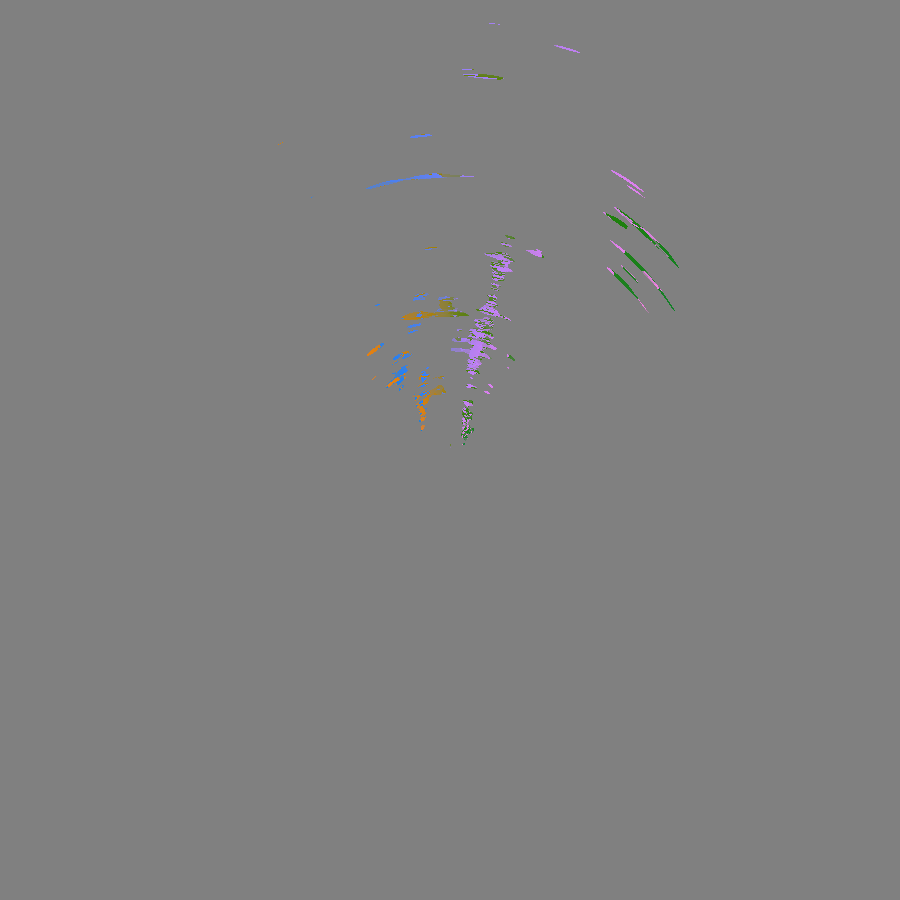

In [5]:
meow("Picking dominant doppler bin at every range and angle pixel")
peak_doppler_indices = numpy.argmax(azimuth_spectrum, axis=2)
raw_doppler_bins = peak_doppler_indices * 2
signed_bins = (
    (raw_doppler_bins.astype(numpy.int32) + chirps_per_frame // 2)
    % chirps_per_frame
) - chirps_per_frame // 2
polar_velocity = (signed_bins * 0.1).T.astype(numpy.float32)
meow("Warping polar velocity onto cartesian canvas")
cartesian_velocity = cv2.remap(
    polar_velocity, angle_indices, range_indices,
    interpolation=cv2.INTER_NEAREST,
    borderMode=cv2.BORDER_CONSTANT, borderValue=0
) * inside_field_of_view
meow("Lifting radial velocity to world vector")
unit_range = numpy.maximum(pixel_range, 1)
velocity_x = cartesian_velocity * (grid_x / unit_range)
velocity_y = cartesian_velocity * (grid_y / unit_range)
meow("Encoding velocity in normal-map style")
max_velocity_mps = (chirps_per_frame // 2) * 0.1
signal_mask = canvas > 0.25
vx_factor = numpy.sign(velocity_x) * numpy.sqrt(
    numpy.clip(numpy.abs(velocity_x) / max_velocity_mps, 0, 1)
)
vy_factor = numpy.sign(velocity_y) * numpy.sqrt(
    numpy.clip(numpy.abs(velocity_y) / max_velocity_mps, 0, 1)
)
flow_map_r = numpy.clip(
    128 + vx_factor * 127 * signal_mask, 0, 255
).astype(numpy.uint8)
flow_map_g = numpy.full_like(flow_map_r, 128)
flow_map_b = numpy.clip(
    128 + vy_factor * 127 * signal_mask, 0, 255
).astype(numpy.uint8)
flow_map = numpy.stack([flow_map_b, flow_map_g, flow_map_r], axis=-1)
print()
_, png = cv2.imencode(".png", flow_map)
IPython.display.display(IPython.display.Image(png.tobytes()))

In [6]:
meow("Bringing camera-radar transforms")
if not os.path.exists("camera_calib.npy"):
    address = (
        "https://raw.githubusercontent.com/"
        "LiuLiu-55/ROFusion/main/"
        "camera_calib.npy"
    )
    !wget -q "$address" -O "camera_calib.npy"
camera_calibration = numpy.load(
    "camera_calib.npy", allow_pickle=True
).item()
intrinsic_matrix = camera_calibration["intrinsic"]["camera_matrix"]
distortion = camera_calibration["intrinsic"]["distortion_coefficients"]
rotation_vector = camera_calibration["extrinsic"]["rotation_vector"]
translation_vector = camera_calibration["extrinsic"]["translation_vector"]
rotation_matrix, _ = cv2.Rodrigues(rotation_vector)
camera_origin_in_radar = -rotation_matrix.T @ translation_vector

🐾 Bringing camera-radar transforms nyaa~


In [7]:
meow("Defining helpers for camera and minimap")
calibration_full_width = 1920
calibration_full_height = 1080
def camera_uv_to_minimap_uv(camera_u, camera_v):
    pixel_x = camera_u * calibration_full_width
    pixel_y = camera_v * calibration_full_height
    pixels = numpy.stack(
        [pixel_x.ravel(), pixel_y.ravel()], axis=-1
    ).astype(numpy.float32).reshape(-1, 1, 2)
    undistorted = cv2.undistortPoints(
        pixels, intrinsic_matrix, distortion
    ).reshape(-1, 2)
    rays_camera = numpy.column_stack(
        [undistorted, numpy.ones(len(undistorted))]
    )
    rays_radar = rays_camera @ rotation_matrix
    t_param = -camera_origin_in_radar[2] / rays_radar[:, 2]
    ground_x = camera_origin_in_radar[0] + t_param * rays_radar[:, 0]
    ground_y = camera_origin_in_radar[1] + t_param * rays_radar[:, 1]
    minimap_u = (ground_x + max_range_meters) / (2 * max_range_meters)
    minimap_v = (max_range_meters - ground_y) / (2 * max_range_meters)
    return (
        minimap_u.reshape(camera_u.shape),
        minimap_v.reshape(camera_v.shape)
    )
def sample_velocity_at_minimap_uv(minimap_u, minimap_v):
    pixel_x = (minimap_u * canvas_size).astype(numpy.int32)
    pixel_y = (minimap_v * canvas_size).astype(numpy.int32)
    in_bounds = (
        (pixel_x >= 0) & (pixel_x < canvas_size)
        & (pixel_y >= 0) & (pixel_y < canvas_size)
    )
    pixel_x = numpy.clip(pixel_x, 0, canvas_size - 1)
    pixel_y = numpy.clip(pixel_y, 0, canvas_size - 1)
    has_signal = in_bounds & (canvas[pixel_y, pixel_x] > 0.25)
    sampled_x = numpy.where(has_signal, velocity_x[pixel_y, pixel_x], 0)
    sampled_y = numpy.where(has_signal, velocity_y[pixel_y, pixel_x], 0)
    return sampled_x, sampled_y

🐾 Defining helpers for camera and minimap nyaa~


🐾 Pulling camera frame for overlay nyaa~
🐾 Sampling velocity nyaa~
🐾 Encoding sampled velocity in normal-map style nyaa~
🐾 Blending overlay onto camera nyaa~



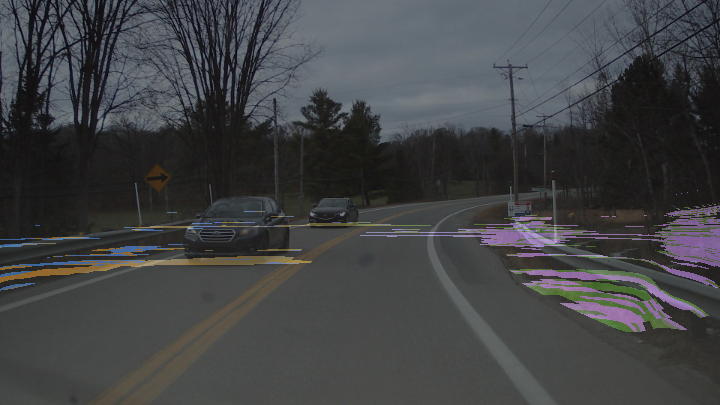

In [8]:
meow("Pulling camera frame for overlay")
with open(recording + "_camera.mjpg", "rb") as file:
    mjpg = mmap.mmap(file.fileno(), 0, access=mmap.ACCESS_READ)
position = 0
for _ in range(camera_frame_index + 1):
    position = mjpg.find(b"\xFF\xD8", position) + 2
start = position - 2
end = mjpg.find(b"\xFF\xD8", position)
if end == -1:
    end = len(mjpg)
camera = cv2.imdecode(
    numpy.frombuffer(mjpg, dtype=numpy.uint8, offset=start, count=end - start),
    cv2.IMREAD_REDUCED_COLOR_2
)
meow("Sampling velocity")
overlay_width = 720
overlay_height = 405
overlay_u, overlay_v = numpy.meshgrid(
    numpy.linspace(0, 1, overlay_width, dtype=numpy.float32),
    numpy.linspace(0, 1, overlay_height, dtype=numpy.float32)
)
sampled_minimap_u, sampled_minimap_v = camera_uv_to_minimap_uv(
    overlay_u, overlay_v
)
sampled_velocity_x, sampled_velocity_y = sample_velocity_at_minimap_uv(
    sampled_minimap_u, sampled_minimap_v
)
meow("Encoding sampled velocity in normal-map style")
vx_factor = numpy.sign(sampled_velocity_x) * numpy.sqrt(
    numpy.clip(numpy.abs(sampled_velocity_x) / max_velocity_mps, 0, 1)
)
vy_factor = numpy.sign(sampled_velocity_y) * numpy.sqrt(
    numpy.clip(numpy.abs(sampled_velocity_y) / max_velocity_mps, 0, 1)
)
overlay_r = numpy.clip(128 + vx_factor * 127, 0, 255).astype(numpy.uint8)
overlay_g = numpy.full_like(overlay_r, 128)
overlay_b = numpy.clip(128 + vy_factor * 127, 0, 255).astype(numpy.uint8)
no_signal = (sampled_velocity_x == 0) & (sampled_velocity_y == 0)
overlay_r[no_signal] = 0
overlay_g[no_signal] = 0
overlay_b[no_signal] = 0
overlay_color = numpy.stack([overlay_b, overlay_g, overlay_r], axis=-1)
meow("Blending overlay onto camera")
camera_resized = cv2.resize(camera, (overlay_width, overlay_height))
camera_with_overlay = cv2.addWeighted(
    camera_resized, 0.5, overlay_color, 0.5, 0
)
print()
_, png = cv2.imencode(".png", camera_with_overlay)
IPython.display.display(IPython.display.Image(png.tobytes()))

🐾 Sampling canvas intensity and velocity nyaa~
🐾 Preparing distance grid in camera space nyaa~
🐾 Preparing speed magnitude nyaa~
🐾 Preparing vertical and horizontal velocity visualizations nyaa~
🐾 Drawing legends nyaa~
🐾 Stitching everything nyaa~



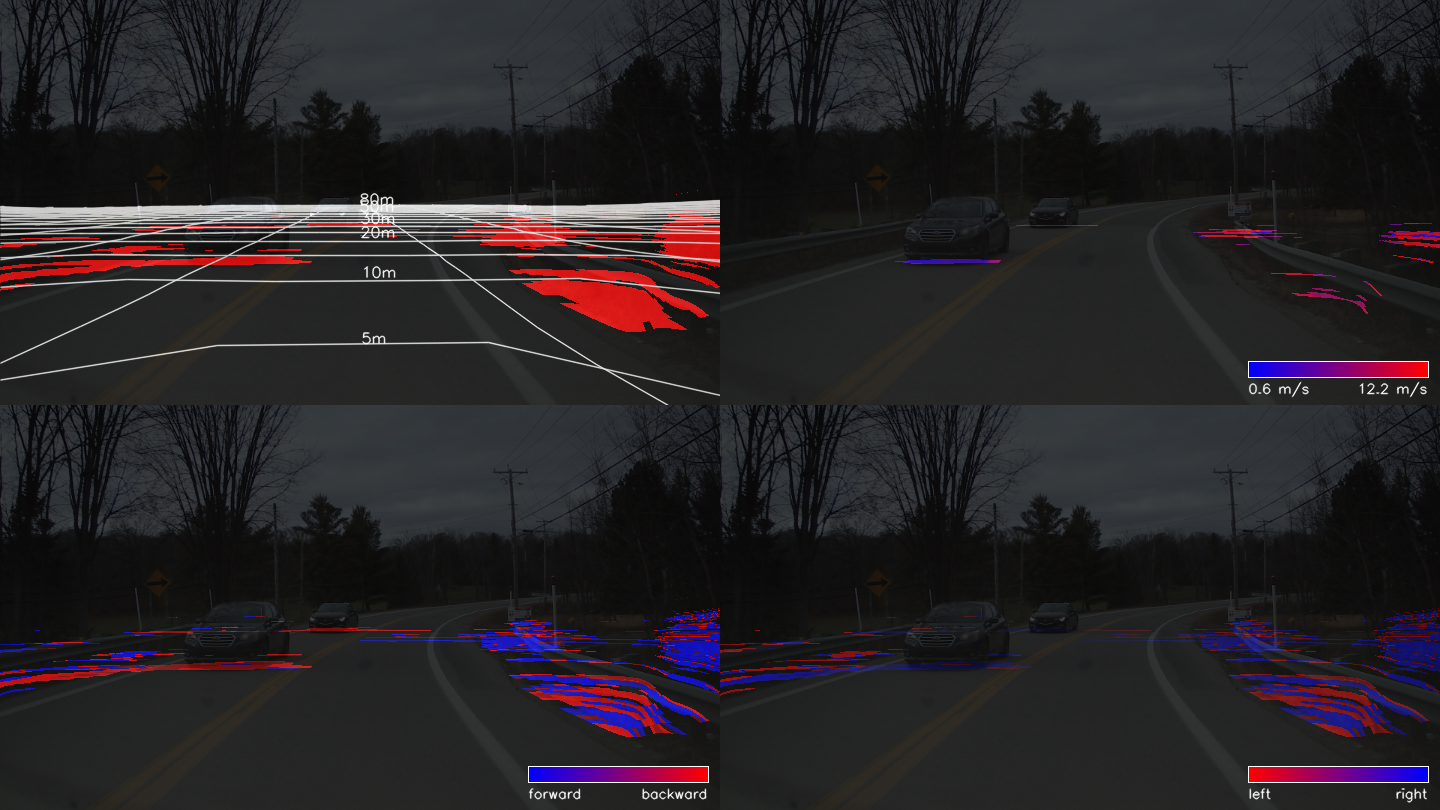

In [9]:
meow("Sampling canvas intensity and velocity")
safe_minimap_u = numpy.nan_to_num(
    sampled_minimap_u, nan=-1.0, posinf=-1.0, neginf=-1.0
)
safe_minimap_v = numpy.nan_to_num(
    sampled_minimap_v, nan=-1.0, posinf=-1.0, neginf=-1.0
)
panel_pixel_x = numpy.clip(
    (safe_minimap_u * canvas_size).astype(numpy.int32),
    0, canvas_size - 1
)
panel_pixel_y = numpy.clip(
    (safe_minimap_v * canvas_size).astype(numpy.int32),
    0, canvas_size - 1
)
panel_in_bounds = (
    (safe_minimap_u >= 0) & (safe_minimap_u < 1)
    & (safe_minimap_v >= 0) & (safe_minimap_v < 1)
)
panel_canvas = canvas[panel_pixel_y, panel_pixel_x] * panel_in_bounds
panel_vx = velocity_x[panel_pixel_y, panel_pixel_x] * panel_in_bounds
panel_vy = velocity_y[panel_pixel_y, panel_pixel_x] * panel_in_bounds
panel_display_scale = numpy.array([
    overlay_width / calibration_full_width,
    overlay_height / calibration_full_height
])
meow("Preparing distance grid in camera space")
tl_overlay = numpy.zeros_like(camera_resized)
tl_overlay[panel_canvas > 0.25, 2] = 255
def project_world_polyline(world_points, destination):
    projected, _ = cv2.projectPoints(
        world_points, rotation_vector, translation_vector,
        intrinsic_matrix, distortion
    )
    projected = projected.reshape(-1, 2) * panel_display_scale
    in_range = numpy.isfinite(projected).all(axis=1) & (
        numpy.abs(projected).max(axis=1) < 1e6
    )
    if in_range.sum() < 2:
        return
    cv2.polylines(
        destination,
        [projected[in_range].astype(numpy.int32).reshape(-1, 1, 2)],
        False, (255, 255, 255), 1, cv2.LINE_AA
    )
grid_spacing_meters = 5.0
for distance in numpy.arange(
    grid_spacing_meters, max_range_meters + 1e-3, grid_spacing_meters
):
    line_xs = numpy.linspace(-max_range_meters, max_range_meters, 80)
    project_world_polyline(
        numpy.column_stack([
            line_xs,
            numpy.full_like(line_xs, distance),
            numpy.zeros_like(line_xs)
        ]).astype(numpy.float64),
        tl_overlay
    )
for offset in numpy.arange(
    -max_range_meters, max_range_meters + 1e-3, grid_spacing_meters
):
    line_ys = numpy.linspace(0.5, max_range_meters, 80)
    project_world_polyline(
        numpy.column_stack([
            numpy.full_like(line_ys, offset),
            line_ys,
            numpy.zeros_like(line_ys)
        ]).astype(numpy.float64),
        tl_overlay
    )
tl_panel = cv2.addWeighted(camera_resized, 0.25, tl_overlay, 0.75, 0)
label_distances = (5, 10, 20, 30, 50, 80)
label_points_world = numpy.array(
    [[0, d, 0] for d in label_distances], dtype=numpy.float64
)
label_pixels, _ = cv2.projectPoints(
    label_points_world, rotation_vector, translation_vector,
    intrinsic_matrix, distortion
)
label_pixels = label_pixels.reshape(-1, 2) * panel_display_scale
for distance, (label_u, label_v) in zip(label_distances, label_pixels):
    label_u = int(round(label_u))
    label_v = int(round(label_v))
    if 0 <= label_v < overlay_height:
        cv2.putText(
            tl_panel, f"{distance}m", (label_u + 6, label_v - 4),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA
        )
meow("Preparing speed magnitude")
speed_intensity_floor = 0.55
min_speed_mps = 0.5
panel_speed = numpy.hypot(panel_vx, panel_vy)
speed_mask = (
    (panel_canvas > speed_intensity_floor)
    & (panel_speed >= min_speed_mps)
)
tr_overlay = numpy.zeros_like(camera_resized)
if speed_mask.any():
    speed_min = float(panel_speed[speed_mask].min())
    speed_max = float(panel_speed[speed_mask].max())
    if speed_max - speed_min > 1e-6:
        speed_norm = numpy.clip(
            (panel_speed - speed_min) / (speed_max - speed_min), 0, 1
        )
    else:
        speed_norm = numpy.zeros_like(panel_speed)
    tr_overlay[..., 0] = ((1 - speed_norm) * 255 * speed_mask).astype(numpy.uint8)
    tr_overlay[..., 2] = (speed_norm * 255 * speed_mask).astype(numpy.uint8)
else:
    speed_min, speed_max = 0.0, 0.0
tr_panel = cv2.addWeighted(camera_resized, 0.25, tr_overlay, 0.75, 0)
meow("Preparing vertical and horizontal velocity visualizations")
signal_mask = panel_canvas > 0.25
closing = numpy.sqrt(numpy.clip(-panel_vy / max_velocity_mps, 0, 1))
receding = numpy.sqrt(numpy.clip(panel_vy / max_velocity_mps, 0, 1))
bl_overlay = numpy.zeros_like(camera_resized)
bl_overlay[..., 0] = (receding * 255 * signal_mask).astype(numpy.uint8)
bl_overlay[..., 2] = (closing * 255 * signal_mask).astype(numpy.uint8)
bl_panel = cv2.addWeighted(camera_resized, 0.25, bl_overlay, 0.75, 0)
going_left = numpy.sqrt(numpy.clip(-panel_vx / max_velocity_mps, 0, 1))
going_right = numpy.sqrt(numpy.clip(panel_vx / max_velocity_mps, 0, 1))
br_overlay = numpy.zeros_like(camera_resized)
br_overlay[..., 0] = (going_right * 255 * signal_mask).astype(numpy.uint8)
br_overlay[..., 2] = (going_left * 255 * signal_mask).astype(numpy.uint8)
br_panel = cv2.addWeighted(camera_resized, 0.25, br_overlay, 0.75, 0)
meow("Drawing legends")
def draw_color_bar(image, left_color, right_color, left_label, right_label):
    bar_width = 180
    bar_height = 16
    margin = 12
    height, width = image.shape[:2]
    x0 = width - bar_width - margin
    y0 = height - bar_height - 28
    gradient_t = numpy.linspace(
        0, 1, bar_width, dtype=numpy.float32
    )[None, :, None]
    left_arr = numpy.asarray(left_color, dtype=numpy.float32)[None, None, :]
    right_arr = numpy.asarray(right_color, dtype=numpy.float32)[None, None, :]
    gradient = (
        left_arr * (1 - gradient_t) + right_arr * gradient_t
    ).astype(numpy.uint8)
    image[y0:y0 + bar_height, x0:x0 + bar_width] = numpy.repeat(
        gradient, bar_height, axis=0
    )
    cv2.rectangle(
        image, (x0, y0), (x0 + bar_width, y0 + bar_height),
        (255, 255, 255), 1
    )
    cv2.putText(
        image, left_label, (x0, y0 + bar_height + 16),
        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA
    )
    right_text_size = cv2.getTextSize(
        right_label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1
    )[0]
    cv2.putText(
        image, right_label,
        (x0 + bar_width - right_text_size[0], y0 + bar_height + 16),
        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA
    )
draw_color_bar(
    tr_panel, (255, 0, 0), (0, 0, 255),
    f"{speed_min:.1f} m/s", f"{speed_max:.1f} m/s"
)
draw_color_bar(bl_panel, (255, 0, 0), (0, 0, 255), "forward", "backward")
draw_color_bar(br_panel, (0, 0, 255), (255, 0, 0), "left", "right")
meow("Stitching everything")
panel_2x2 = numpy.vstack([
    numpy.hstack([tl_panel, tr_panel]),
    numpy.hstack([bl_panel, br_panel])
])
print()
_, png = cv2.imencode(".png", panel_2x2)
IPython.display.display(IPython.display.Image(png.tobytes()))

🐾 Loading YOLOv8 model nyaa~
🐾 Running object detection on the current camera frame nyaa~
🐾 Defining data sampler for velocity and distance nyaa~
🐾 Fusing radar velocities and distances with detected bounding boxes nyaa~
🐾 Displaying YOLO + Radar Fusion nyaa~



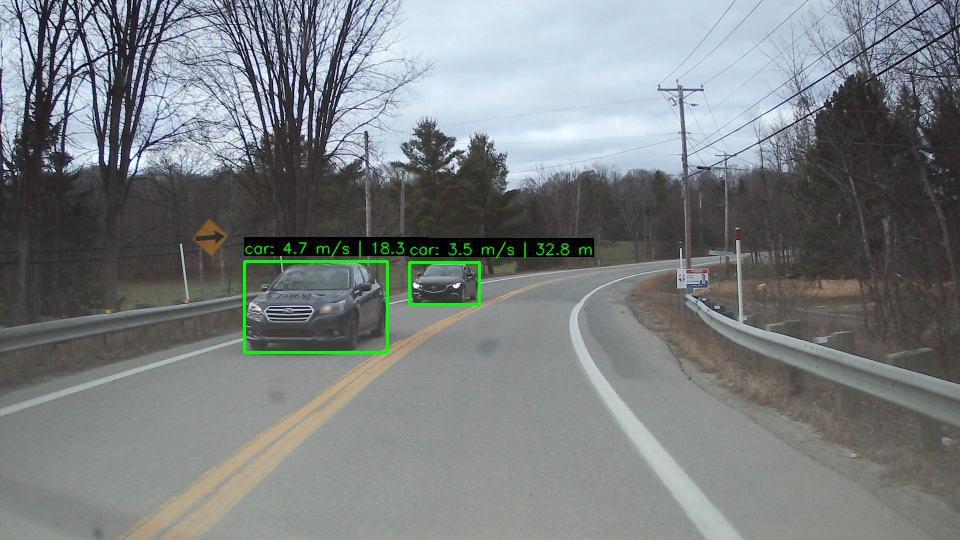

In [13]:
#----------------------------------
# Car detection using YOLO
#----------------------------------
# Install ultralytics
try:
    from ultralytics import YOLO
except ImportError:
    !pip install -q ultralytics
    from ultralytics import YOLO

meow("Loading YOLOv8 model")
# We use the nano (n) model for fast inference
yolo_model = YOLO("yolov8n.pt")

meow("Running object detection on the current camera frame")
# Suppress the verbose YOLO logging output for a cleaner console
results = yolo_model(camera, verbose=False)

annotated_camera = camera.copy()

meow("Defining data sampler for velocity and distance")
def sample_data_at_minimap_uv(minimap_u, minimap_v):
    pixel_x = (minimap_u * canvas_size).astype(numpy.int32)
    pixel_y = (minimap_v * canvas_size).astype(numpy.int32)
    in_bounds = (
        (pixel_x >= 0) & (pixel_x < canvas_size)
        & (pixel_y >= 0) & (pixel_y < canvas_size)
    )
    pixel_x = numpy.clip(pixel_x, 0, canvas_size - 1)
    pixel_y = numpy.clip(pixel_y, 0, canvas_size - 1)

    # Check where radar signal is reasonably strong
    has_signal = in_bounds & (canvas[pixel_y, pixel_x] > 0.25)

    sampled_x = numpy.where(has_signal, velocity_x[pixel_y, pixel_x], 0)
    sampled_y = numpy.where(has_signal, velocity_y[pixel_y, pixel_x], 0)
    # Pull distance from the global pixel_range map
    sampled_dist = numpy.where(has_signal, pixel_range[pixel_y, pixel_x], 0)

    return sampled_x, sampled_y, sampled_dist

meow("Fusing radar velocities and distances with detected bounding boxes")
# Standard COCO dataset classes for vehicles: 2=car, 3=motorcycle, 5=bus, 7=truck
target_classes = [2, 3, 5, 7]

for box in results[0].boxes:
    cls_id = int(box.cls[0])

    # Skip detecting people, stop signs, etc.
    if cls_id not in target_classes:
        continue

    # Extract the bounding box coordinates
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

    # Get image dimensions to calculate normalized UV coordinates
    h, w = camera.shape[:2]

    # Create a dense grid of points inside the bounding box.
    # We sample every ~2 pixels to keep the processing highly performant.
    u_vals = numpy.linspace(x1/w, x2/w, num=int((x2-x1)/2))
    v_vals = numpy.linspace(y1/h, y2/h, num=int((y2-y1)/2))
    box_u, box_v = numpy.meshgrid(u_vals, v_vals)

    # Map the bounding box camera UVs to the Radar Minimap UVs
    mini_u, mini_v = camera_uv_to_minimap_uv(box_u, box_v)

    # Sample the corresponding velocities and distances from the radar canvas
    vx, vy, dists = sample_data_at_minimap_uv(mini_u, mini_v)

    # Calculate absolute speed magnitude in meters per second
    speeds = numpy.hypot(vx, vy)

    # Use distance > 0 as our valid signal mask (filters out empty radar space)
    valid_mask = dists > 0
    valid_speeds = speeds[valid_mask]
    valid_dists = dists[valid_mask]

    if len(valid_speeds) > 0:
        # Average the valid radar returns inside the bounding box
        avg_speed = numpy.mean(valid_speeds)
        avg_dist = numpy.mean(valid_dists)
        label = f"{yolo_model.names[cls_id]}: {avg_speed:.1f} m/s | {avg_dist:.1f} m"
        color = (0, 255, 0) # Green for successful radar capture
    else:
        # Box was found, but no radar points hit the ground plane inside this area
        label = f"{yolo_model.names[cls_id]}: No Radar Data"
        color = (0, 0, 255) # Red for missing radar

    # Draw the bounding box
    cv2.rectangle(annotated_camera, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)

    # Draw a dark background block for the text to improve readability
    (txt_w, txt_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    txt_start_y = max(10, int(y1) - 8)
    cv2.rectangle(annotated_camera, (int(x1), txt_start_y - txt_h - 4), (int(x1) + txt_w, txt_start_y + 2), (0, 0, 0), -1)

    # Draw the text label
    cv2.putText(
        annotated_camera, label, (int(x1), txt_start_y),
        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA
    )

meow("Displaying YOLO + Radar Fusion")
print()
_, png = cv2.imencode(".png", annotated_camera)
IPython.display.display(IPython.display.Image(png.tobytes()))

In [14]:
import tqdm
import numpy

# Make sure YOLO is available
try:
    from ultralytics import YOLO
except ImportError:
    !pip install -q ultralytics
    from ultralytics import YOLO

meow("Loading YOLOv8 model for video processing...")
yolo_model = YOLO("yolov8n.pt")

meow("Indexing MJPEG frames to speed up video rendering...")
with open(recording + "_camera.mjpg", "rb") as file:
    mjpg = mmap.mmap(file.fileno(), 0, access=mmap.ACCESS_READ)

mjpg_frame_starts = []
pos = 0
while True:
    pos = mjpg.find(b"\xFF\xD8", pos)
    if pos == -1:
        break
    mjpg_frame_starts.append(pos)
    pos += 2

def process_frame(camera_frame_index):
    """Processes a single frame, fuses radar data, dims the background, and overlays boxes."""

    # --- 1. RADAR PROCESSING ---
    radar_frame_indices = camera_to_radar[camera_frame_index]

    chip_samples = [
        numpy.fromfile(
            path, dtype=numpy.int16,
            count=int16_values_per_frame,
            offset=index * bytes_per_frame
        )
        for path, index in zip(radar_paths, radar_frame_indices)
    ]

    chips = []
    for chip_index in (3, 0, 1, 2):
        samples = chip_samples[chip_index]
        chips.append(numpy.reshape(
            samples[0::2] + 1j * samples[1::2],
            (samples_per_chirp, receivers_per_chip, chirps_per_frame),
            order="F"
        ).transpose((0, 2, 1)))

    radar_cube = numpy.concatenate(chips, axis=2).astype(numpy.complex64)
    radar_cube -= numpy.mean(radar_cube, axis=(0, 1), keepdims=True)

    range_fft = numpy.fft.fft(
        radar_cube * range_window,
        n=samples_per_chirp, axis=0
    )
    radar_fft = numpy.fft.fft(
        range_fft * doppler_window,
        n=chirps_per_frame, axis=1
    ).astype(numpy.complex64)

    mimo_spectrum = radar_fft[:, doppler_indices, :].reshape(
        radar_fft.shape[0] * doppler_indices.shape[0], -1
    )
    mimo_spectrum = (mimo_spectrum * calibration_window).T
    azimuth_spectrum = numpy.abs(
        numpy.dot(calibration_matrix, mimo_spectrum)
    )
    azimuth_spectrum = azimuth_spectrum.reshape(
        len(azimuth_degrees),
        radar_fft.shape[0],
        doppler_indices.shape[0]
    )

    polar_map = numpy.log10(
        numpy.sum(numpy.abs(azimuth_spectrum), axis=2) + 1e-6
    )
    polar_map -= polar_map.min()
    if polar_map.max() > 0:
        polar_map = polar_map / polar_map.max()
    polar_map = polar_map.T.astype(numpy.float32)

    noise_floor = numpy.percentile(polar_map, 72, axis=1, keepdims=True)
    polar_map = numpy.clip(polar_map - noise_floor, 0, None)
    polar_map = cv2.GaussianBlur(polar_map, (0, 0), 1.0)
    if polar_map.max() > 0:
        polar_map = polar_map / polar_map.max()

    warped = cv2.remap(
        polar_map, angle_indices, range_indices,
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )
    canvas = warped * inside_field_of_view

    # --- 2. VELOCITY MAP ---
    peak_doppler_indices = numpy.argmax(azimuth_spectrum, axis=2)
    raw_doppler_bins = peak_doppler_indices * 2
    signed_bins = (
        (raw_doppler_bins.astype(numpy.int32) + chirps_per_frame // 2)
    ) - chirps_per_frame // 2
    polar_velocity = (signed_bins * 0.1).T.astype(numpy.float32)

    cartesian_velocity = cv2.remap(
        polar_velocity, angle_indices, range_indices,
        interpolation=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT, borderValue=0
    ) * inside_field_of_view

    unit_range = numpy.maximum(pixel_range, 1)
    velocity_x = cartesian_velocity * (grid_x / unit_range)
    velocity_y = cartesian_velocity * (grid_y / unit_range)

    # --- 3. CAMERA EXTRACTION ---
    start = mjpg_frame_starts[camera_frame_index]
    end = mjpg_frame_starts[camera_frame_index + 1] if camera_frame_index + 1 < len(mjpg_frame_starts) else len(mjpg)

    camera = cv2.imdecode(
        numpy.frombuffer(mjpg, dtype=numpy.uint8, offset=start, count=end - start),
        cv2.IMREAD_REDUCED_COLOR_2
    )
    camera_resized = cv2.resize(camera, (overlay_width, overlay_height))

    # --- 4. DATA SAMPLING FUNCTION ---
    def sample_data_at_minimap_uv(minimap_u, minimap_v):
        pixel_x = (minimap_u * canvas_size).astype(numpy.int32)
        pixel_y = (minimap_v * canvas_size).astype(numpy.int32)
        in_bounds = (
            (pixel_x >= 0) & (pixel_x < canvas_size)
            & (pixel_y >= 0) & (pixel_y < canvas_size)
        )
        pixel_x = numpy.clip(pixel_x, 0, canvas_size - 1)
        pixel_y = numpy.clip(pixel_y, 0, canvas_size - 1)

        has_signal = in_bounds & (canvas[pixel_y, pixel_x] > 0.25)

        sampled_x = numpy.where(has_signal, velocity_x[pixel_y, pixel_x], 0)
        sampled_y = numpy.where(has_signal, velocity_y[pixel_y, pixel_x], 0)
        sampled_dist = numpy.where(has_signal, pixel_range[pixel_y, pixel_x], 0)

        return sampled_x, sampled_y, sampled_dist

    # --- 5. YOLO + RADAR FUSION ---
    results = yolo_model(camera, verbose=False)
    target_classes = [2, 3, 5, 7] # Cars, motorcycles, buses, trucks

    yolo_boxes_to_draw = []

    # Initialize a blank mask to keep track of where the cars are
    car_mask = numpy.zeros((overlay_height, overlay_width), dtype=bool)

    for box in results[0].boxes:
        cls_id = int(box.cls[0])
        if cls_id not in target_classes:
            continue

        nx1, ny1, nx2, ny2 = box.xyxyn[0].cpu().numpy()
        rx1, ry1 = int(nx1 * overlay_width), int(ny1 * overlay_height)
        rx2, ry2 = int(nx2 * overlay_width), int(ny2 * overlay_height)

        # Mark this bounding box area as True on the mask (safeguarding bounds)
        safe_rx1, safe_ry1 = max(0, rx1), max(0, ry1)
        safe_rx2, safe_ry2 = min(overlay_width, rx2), min(overlay_height, ry2)
        car_mask[safe_ry1:safe_ry2, safe_rx1:safe_rx2] = True

        u_vals = numpy.linspace(nx1, nx2, num=max(1, int((rx2-rx1)/2)))
        v_vals = numpy.linspace(ny1, ny2, num=max(1, int((ry2-ry1)/2)))
        box_u, box_v = numpy.meshgrid(u_vals, v_vals)

        mini_u, mini_v = camera_uv_to_minimap_uv(box_u, box_v)
        vx, vy, dists = sample_data_at_minimap_uv(mini_u, mini_v)

        speeds = numpy.hypot(vx, vy)
        valid_mask = dists > 0
        valid_speeds = speeds[valid_mask]
        valid_dists = dists[valid_mask]

        if len(valid_speeds) > 0:
            avg_speed = numpy.mean(valid_speeds)
            avg_dist = numpy.mean(valid_dists)
            label = f"{yolo_model.names[cls_id]}: {avg_speed:.1f} m/s | {avg_dist:.1f} m"
            color = (0, 255, 0)
        else:
            label = f"{yolo_model.names[cls_id]}: No Radar"
            color = (0, 0, 255)

        yolo_boxes_to_draw.append({
            "pt1": (rx1, ry1),
            "pt2": (rx2, ry2),
            "label": label,
            "color": color
        })

    # --- 6. APPLY BACKGROUND DIMMING ---
    # Create a 30% brightness version of the camera
    dimmed_camera = (camera_resized * 0.3).astype(numpy.uint8)
    # Combine them: Use normal camera where mask is True, dimmed camera where False
    camera_resized = numpy.where(car_mask[..., None], camera_resized, dimmed_camera)

    # --- 7. OVERLAYS & SAMPLING ---
    sampled_minimap_u, sampled_minimap_v = camera_uv_to_minimap_uv(overlay_u, overlay_v)
    safe_minimap_u = numpy.nan_to_num(sampled_minimap_u, nan=-1.0, posinf=-1.0, neginf=-1.0)
    safe_minimap_v = numpy.nan_to_num(sampled_minimap_v, nan=-1.0, posinf=-1.0, neginf=-1.0)

    panel_pixel_x = numpy.clip((safe_minimap_u * canvas_size).astype(numpy.int32), 0, canvas_size - 1)
    panel_pixel_y = numpy.clip((safe_minimap_v * canvas_size).astype(numpy.int32), 0, canvas_size - 1)
    panel_in_bounds = ((safe_minimap_u >= 0) & (safe_minimap_u < 1) & (safe_minimap_v >= 0) & (safe_minimap_v < 1))

    panel_canvas = canvas[panel_pixel_y, panel_pixel_x] * panel_in_bounds
    panel_vx = velocity_x[panel_pixel_y, panel_pixel_x] * panel_in_bounds
    panel_vy = velocity_y[panel_pixel_y, panel_pixel_x] * panel_in_bounds

    # --- 8. TOP-LEFT: Distance Grid ---
    tl_overlay = numpy.zeros_like(camera_resized)
    tl_overlay[panel_canvas > 0.25, 2] = 255

    def project_world_polyline(world_points, destination):
        projected, _ = cv2.projectPoints(world_points, rotation_vector, translation_vector, intrinsic_matrix, distortion)
        projected = projected.reshape(-1, 2) * panel_display_scale
        in_range = numpy.isfinite(projected).all(axis=1) & (numpy.abs(projected).max(axis=1) < 1e6)
        if in_range.sum() < 2: return
        cv2.polylines(destination, [projected[in_range].astype(numpy.int32).reshape(-1, 1, 2)], False, (255, 255, 255), 1, cv2.LINE_AA)

    grid_spacing_meters = 5.0
    for distance in numpy.arange(grid_spacing_meters, max_range_meters + 1e-3, grid_spacing_meters):
        line_xs = numpy.linspace(-max_range_meters, max_range_meters, 80)
        project_world_polyline(numpy.column_stack([line_xs, numpy.full_like(line_xs, distance), numpy.zeros_like(line_xs)]).astype(numpy.float64), tl_overlay)
    for offset in numpy.arange(-max_range_meters, max_range_meters + 1e-3, grid_spacing_meters):
        line_ys = numpy.linspace(0.5, max_range_meters, 80)
        project_world_polyline(numpy.column_stack([numpy.full_like(line_ys, offset), line_ys, numpy.zeros_like(line_ys)]).astype(numpy.float64), tl_overlay)

    tl_panel = cv2.addWeighted(camera_resized, 0.25, tl_overlay, 0.75, 0)

    for distance, (label_u, label_v) in zip(label_distances, label_pixels):
        label_u, label_v = int(round(label_u)), int(round(label_v))
        if 0 <= label_v < overlay_height:
            cv2.putText(tl_panel, f"{distance}m", (label_u + 6, label_v - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

    # --- 9. TOP-RIGHT: Speed Magnitude ---
    panel_speed = numpy.hypot(panel_vx, panel_vy)
    speed_mask = ((panel_canvas > speed_intensity_floor) & (panel_speed >= min_speed_mps))
    tr_overlay = numpy.zeros_like(camera_resized)

    if speed_mask.any():
        speed_min, speed_max = float(panel_speed[speed_mask].min()), float(panel_speed[speed_mask].max())
        speed_norm = numpy.clip((panel_speed - speed_min) / (speed_max - speed_min), 0, 1) if speed_max - speed_min > 1e-6 else numpy.zeros_like(panel_speed)
        tr_overlay[..., 0] = ((1 - speed_norm) * 255 * speed_mask).astype(numpy.uint8)
        tr_overlay[..., 2] = (speed_norm * 255 * speed_mask).astype(numpy.uint8)
    else:
        speed_min, speed_max = 0.0, 0.0
    tr_panel = cv2.addWeighted(camera_resized, 0.25, tr_overlay, 0.75, 0)

    # --- 10. BOTTOM-LEFT/RIGHT: Directional Velocities ---
    signal_mask = panel_canvas > 0.25
    closing = numpy.sqrt(numpy.clip(-panel_vy / max_velocity_mps, 0, 1))
    receding = numpy.sqrt(numpy.clip(panel_vy / max_velocity_mps, 0, 1))
    bl_overlay = numpy.zeros_like(camera_resized)
    bl_overlay[..., 0] = (receding * 255 * signal_mask).astype(numpy.uint8)
    bl_overlay[..., 2] = (closing * 255 * signal_mask).astype(numpy.uint8)
    bl_panel = cv2.addWeighted(camera_resized, 0.25, bl_overlay, 0.75, 0)

    going_left = numpy.sqrt(numpy.clip(-panel_vx / max_velocity_mps, 0, 1))
    going_right = numpy.sqrt(numpy.clip(panel_vx / max_velocity_mps, 0, 1))
    br_overlay = numpy.zeros_like(camera_resized)
    br_overlay[..., 0] = (going_right * 255 * signal_mask).astype(numpy.uint8)
    br_overlay[..., 2] = (going_left * 255 * signal_mask).astype(numpy.uint8)
    br_panel = cv2.addWeighted(camera_resized, 0.25, br_overlay, 0.75, 0)

    # --- 11. DRAW YOLO BOXES ON TOP ---
    for panel in (tl_panel, tr_panel, bl_panel, br_panel):
        for det in yolo_boxes_to_draw:
            cv2.rectangle(panel, det["pt1"], det["pt2"], det["color"], 2)

            (txt_w, txt_h), _ = cv2.getTextSize(det["label"], cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            txt_x, txt_y = det["pt1"][0], max(10, det["pt1"][1] - 8)
            cv2.rectangle(panel, (txt_x, txt_y - txt_h - 2), (txt_x + txt_w, txt_y + 2), (0, 0, 0), -1)

            cv2.putText(
                panel, det["label"], (txt_x, txt_y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, det["color"], 1, cv2.LINE_AA
            )

    # --- 12. LEGENDS & STITCHING ---
    draw_color_bar(tr_panel, (255, 0, 0), (0, 0, 255), f"{speed_min:.1f} m/s", f"{speed_max:.1f} m/s")
    draw_color_bar(bl_panel, (255, 0, 0), (0, 0, 255), "forward", "backward")
    draw_color_bar(br_panel, (0, 0, 255), (255, 0, 0), "left", "right")

    panel_2x2 = numpy.vstack([
        numpy.hstack([tl_panel, tr_panel]),
        numpy.hstack([bl_panel, br_panel])
    ])

    return panel_2x2

🐾 Loading YOLOv8 model for video processing... nyaa~
🐾 Indexing MJPEG frames to speed up video rendering... nyaa~


In [15]:
def build_video(output_filename="output_radar_fused_spotlight.mp4", fps=10.0):
    sorted_indices = sorted(camera_to_radar.keys())
    if not sorted_indices:
        meow("No frames to process!")
        return

    meow(f"Generating video with {len(sorted_indices)} frames...")

    first_frame = process_frame(sorted_indices[0])
    height, width, _ = first_frame.shape

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = cv2.VideoWriter(output_filename, fourcc, fps, (width, height))

    for index in tqdm.tqdm(sorted_indices, desc="\U0001F43E Rendering"):
        try:
            frame_img = process_frame(index)
            video_writer.write(frame_img)
        except Exception as e:
            print(f"Skipping frame {index} due to error: {e}")

    video_writer.release()
    meow(f"Done! Video saved to {output_filename}")

# Run the build
build_video(output_filename="output_radar_fused_spotlight.mp4", fps=10.0)

🐾 Generating video with 548 frames... nyaa~


🐾 Rendering: 100%|██████████| 548/548 [30:13<00:00,  3.31s/it]

🐾 Done! Video saved to output_radar_fused_spotlight.mp4 nyaa~
